## <center>COMP8240 - Project Final</center>
## <center>Parameter-Efficient Sentiment Classification with LoRA: Replication and Extension on Multi-Domain Reviews</center>

#### Student name: Jerry britto John britto
#### Student id: 48682497

In [5]:
# 0. Importing required libraries
import os, random
import json
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# Hugging Face + metrics
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers.training_args import IntervalStrategy 
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# PEFT/LoRA
from peft import LoraConfig, get_peft_model, TaskType

### Our Datasets (Amazon product reviews & Women's Clothing)

In [4]:
# 1. Loading our CSV files
prod_rev = pd.read_csv("amazon product reviews.csv", encoding='utf-8')
cloth_rev = pd.read_csv("Womens Clothing E-Commerce Reviews.csv", encoding='utf-8')

In [5]:
# Checking first few rows of each
print("Amazon Products Reviews Preview:")
display(prod_rev.head())

print("\nWomen’s Clothing Reviews Preview:")
display(cloth_rev.head())

Amazon Products Reviews Preview:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...



Women’s Clothing Reviews Preview:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [6]:
# Showing column names
print("\nColumns in Amazon Products Reviews:", prod_rev.columns.tolist())
print("Columns in Women’s Clothing Reviews:", cloth_rev.columns.tolist())


Columns in Amazon Products Reviews: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']
Columns in Women’s Clothing Reviews: ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [7]:
# 2. For Amazon product reviews dataset
prod_rev = prod_rev.rename(columns={
    "review_title": "text",
})

# For Women's Clothing dataset
cloth_rev = cloth_rev.rename(columns={
    "Review Text": "text",
    "Rating": "rating",
    "Class Name": "category"
})

# Keeping only necessary columns
prod_rev = prod_rev[["text", "rating", "category"]]
cloth_rev= cloth_rev[["text", "rating", "category"]]

### Cleaing and Normalizing

In [9]:
# 3. Cleaning and Normalizing the Text
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^A-Za-z0-9\s.,!?']", " ", text)  # keep clean characters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

prod_rev["text"] = prod_rev["text"].apply(clean_text)
cloth_rev["text"] = cloth_rev["text"].apply(clean_text)

# Removing short/empty reviews
prod_rev = prod_rev[prod_rev["text"].str.len() > 15]
cloth_rev = cloth_rev[cloth_rev["text"].str.len() > 15]

In [10]:
# 4. Combining both Datasets
prod_cloth_rev = pd.concat([prod_rev, cloth_rev], ignore_index=True)
print("Combined Product & Clothing reviews dataset shape:", prod_cloth_rev.shape)

# If some reviews have no rating (NaN), remove them
prod_cloth_rev = prod_cloth_rev.dropna(subset=["rating"])

prod_cloth_rev.head()

Combined Product & Clothing reviews dataset shape: (24094, 3)


,text,rating,category
0,"satisfied,charging is really fast,value for mo...",4.2,Computers&Accessories|Accessories&Peripherals|...
1,"a good braided cable for your type c device,go...",4.0,Computers&Accessories|Accessories&Peripherals|...
2,"good speed for earlier versions,good product,w...",3.9,Computers&Accessories|Accessories&Peripherals|...
3,"good product,good one,nice,really nice product...",4.2,Computers&Accessories|Accessories&Peripherals|...
4,"as good as original,decent,good one for second...",4.2,Computers&Accessories|Accessories&Peripherals|...


In [11]:
# 5. Creating Sentiment Labels
def label_sentiment(rating):
    try:
        rating = float(rating)
        if rating >= 4.0:
            return "Positive"
        elif 2.5 <= rating < 4.0:
            return "Neutral"
        else:
            return "Negative"
    except:
        return "Unknown"

prod_cloth_rev["label"] = prod_cloth_rev["rating"].apply(label_sentiment)

In [12]:
# 6. Final Cleanup & Saving
final_prod_cloth_rev = prod_cloth_rev[["text", "label", "category"]]
final_prod_cloth_rev.to_csv("final_product_clothes_reviews.csv", index=False)

print("Final dataset saved as 'final_product_clothes_reviews.csv'")
print(final_prod_cloth_rev["label"].value_counts())
prod_cloth_rev.head()

Final dataset saved as 'final_product_clothes_reviews.csv'
label
Positive    18547
Neutral      3174
Negative     2372
Unknown         1
Name: count, dtype: int64


,text,rating,category,label
0,"satisfied,charging is really fast,value for mo...",4.2,Computers&Accessories|Accessories&Peripherals|...,Positive
1,"a good braided cable for your type c device,go...",4.0,Computers&Accessories|Accessories&Peripherals|...,Positive
2,"good speed for earlier versions,good product,w...",3.9,Computers&Accessories|Accessories&Peripherals|...,Neutral
3,"good product,good one,nice,really nice product...",4.2,Computers&Accessories|Accessories&Peripherals|...,Positive
4,"as good as original,decent,good one for second...",4.2,Computers&Accessories|Accessories&Peripherals|...,Positive


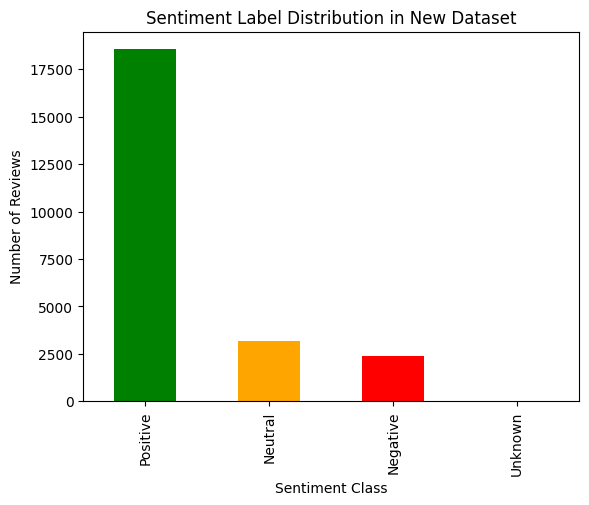

In [13]:
# 7. Check Class Balance
final_prod_cloth_rev["label"].value_counts().plot(kind="bar", color=["green", "orange", "red"])
plt.title("Sentiment Label Distribution in New Dataset")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
plt.show()

### Deduplicate, stratified split, save CSVs, and plotting figures

In [15]:
# 8. DEDUPLICATE + STRATIFIED SPLIT + SAVING + FIGURES

# setting seeds so the split is reproducible
random.seed(42)
np.random.seed(42)

# 8.1) Deduplicate on text+label (keeps first occurrence)
final_prod_cloth_rev = final_prod_cloth_rev.drop_duplicates(
    subset=["text", "label"], keep="first"
).reset_index(drop=True)

print("After deduplication:", final_prod_cloth_rev.shape)

# 8.2) Helper function: stratified split by label
def strat_split(df, label_col="label", train_frac=0.80, dev_frac=0.10, test_frac=0.10):
    """
    Splits a DataFrame into train/dev/test in a stratified way by label.
    Ensures each split roughly preserves class balance.
    """
    assert abs((train_frac + dev_frac + test_frac) - 1.0) < 1e-9, "Split fractions must sum to 1.0"
    train_parts, dev_parts, test_parts = [], [], []
    
    # grouping by label and splitting within each label group
    for lab, group in df.groupby(label_col):
        n = len(group)
        idx = list(range(n))
        random.shuffle(idx)
        n_train = int(train_frac * n)
        n_dev   = int(dev_frac * n)
        n_test  = n - n_train - n_dev
        
        train_idx = idx[:n_train]
        dev_idx   = idx[n_train:n_train+n_dev]
        test_idx  = idx[n_train+n_dev:]
        
        train_parts.append(group.iloc[train_idx])
        dev_parts.append(group.iloc[dev_idx])
        test_parts.append(group.iloc[test_idx])
    
    # combining and shuffling each split once more
    train_df = pd.concat(train_parts).sample(frac=1.0, random_state=42).reset_index(drop=True)
    dev_df   = pd.concat(dev_parts).sample(frac=1.0, random_state=42).reset_index(drop=True)
    test_df  = pd.concat(test_parts).sample(frac=1.0, random_state=42).reset_index(drop=True)
    return train_df, dev_df, test_df

# 8.3) Running the split
train_df, dev_df, test_df = strat_split(final_prod_cloth_rev, label_col="label",
                                             train_frac=0.80, dev_frac=0.10, test_frac=0.10)

print("Train/dev/test shapes:", train_df.shape, dev_df.shape, test_df.shape)

After deduplication: (23816, 3)
Train/dev/test shapes: (19051, 3) (2381, 3) (2384, 3)


Saved: data/processed/products_train.csv data/processed/products_dev.csv data/processed/products_test.csv


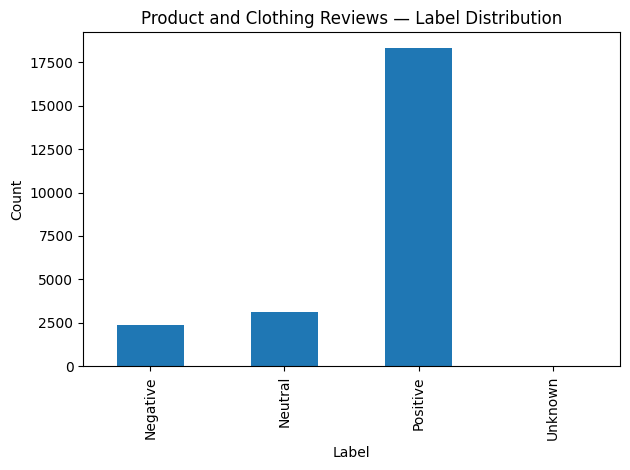

Saved label distribution figure to: data/processed/label_distribution.png


C:\Users\Jerry Britto\AppData\Local\Temp\ipykernel_20696\2133727416.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


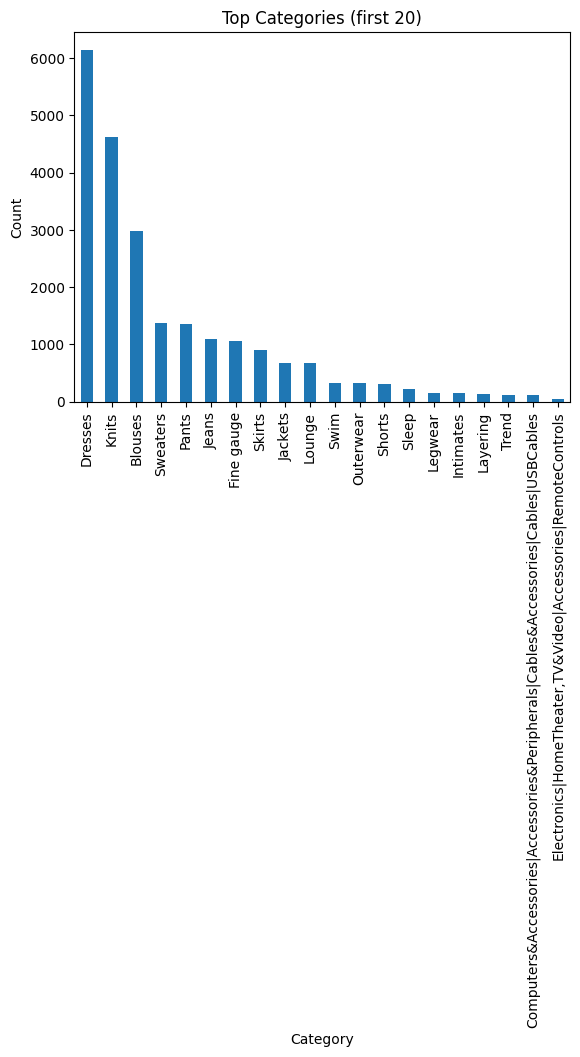

Saved category distribution figure to: data/processed/categ_distribution.png

Snippet for report (text + label + category):
                                                                                                                                                                                                                               text    label                                                                          category
                                                                                                       satisfied,charging is really fast,value for money,product review,good quality,good product,good product,as of now seems good Positive Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables
                                              a good braided cable for your type c device,good quality product from ambrane,super cable,as,good quality,good product,its good,good quality for the price but one issue with my unit Positive C

In [16]:
# 8.4) Saving to folder
os.makedirs("data/processed", exist_ok=True)
train_path = "data/processed/products_train.csv"
dev_path   = "data/processed/products_dev.csv"
test_path  = "data/processed/products_test.csv"

train_df.to_csv(train_path, index=False, encoding="utf-8")
dev_df.to_csv(dev_path, index=False, encoding="utf-8")
test_df.to_csv(test_path, index=False, encoding="utf-8")
print("Saved:", train_path, dev_path, test_path)

# 8.5) Figure 1 — Final label distribution (full cleaned set)
fig1_path = "data/processed/label_distribution.png"
final_prod_cloth_rev["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Product and Clothing Reviews — Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(fig1_path, dpi=150)
plt.show()
print("Saved label distribution figure to:", fig1_path)

# 8.6) (Optional) Figure 2 — Category distribution (quick sanity check)
if "category" in final_prod_cloth_rev.columns:
    fig2_path = "data/processed/categ_distribution.png"
    final_prod_cloth_rev["category"].value_counts().head(20).plot(kind="bar")
    plt.title("Top Categories (first 20)")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(fig2_path, dpi=150)
    plt.show()
    print("Saved category distribution figure to:", fig2_path)

# 8.7) Printing a small snippet
print("\nSnippet for report (text + label + category):")
print(final_prod_cloth_rev[["text", "label", "category"]].head(8).to_string(index=False))

### Training (LoRA) — building, training, and saving best model

In [18]:
# 9. LoRA training
'''
#   1) Loads train/dev CSVs you created earlier
#   2) Tokenizes text for a small transformer (RoBERTa)
#   3) Wraps the classifier with LoRA adapters (freezes base model)
#   4) Trains and saves the BEST model + tokenizer (for later evaluation)

# Requirements (install once in your environment/VM):
#   pip install torch transformers datasets peft scikit-learn matplotlib
'''

# ---------- Paths ----------
TRAIN_CSV = "data/processed/products_train.csv"
DEV_CSV   = "data/processed/products_dev.csv"

# ---------- Labels ----------
LABEL_LIST = ["Negative", "Neutral", "Positive"]
LABEL2ID   = {lab: i for i, lab in enumerate(LABEL_LIST)}
ID2LABEL   = {i: lab for lab, i in LABEL2ID.items()}

# ---------- Model + LoRA config ----------
BASE_MODEL = "roberta-base"
LORA_RANK  = 8                     

# Where to save the trained model + tokenizer
OUT_DIR = f"results/products_lora_r{LORA_RANK}"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------loading CSVs as a HF DatasetDict ----------
def _load_split(path):
    df = pd.read_csv(path)
    assert {"text","label"}.issubset(df.columns), "CSV must have 'text' and 'label' columns"
    df = df[["text","label"]].copy()
    df["labels"] = df["label"].map(LABEL2ID).astype(int)
    return Dataset.from_pandas(df, preserve_index=False)

ds = DatasetDict({
    "train": _load_split(TRAIN_CSV),
    "validation": _load_split(DEV_CSV),
})

# ---------- Tokenizer ----------
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

def _tok(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

# Remove non-model columns after tokenization (i.e., drop 'text' and string 'label')
remove_cols = [c for c in ds["train"].column_names if c not in ["labels", "text"]]
ds_tok = ds.map(_tok, batched=True, remove_columns=remove_cols)

# Tell HF to return PyTorch tensors for just these columns
ds_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# ---------- Building base classifier and wrapping with LoRA ----------
# Tragets for RoBERTa
TARGETS = ["query", "key", "value", "dense"]

# Load a sequence-classification head
base = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABEL_LIST),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

# Configure LoRA
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # sequence classification task
    r=LORA_RANK,                 # low-rank dimension
    lora_alpha=16,               # scaling factor
    lora_dropout=0.05,           # small dropout for stability
    target_modules=TARGETS
)

# Wrap the model with LoRA adapters (base weights are frozen)
model = get_peft_model(base, lora_cfg)
# Nice printout for your report (how many params are trainable)
model.print_trainable_parameters()

# ---------- Metrics for evaluation during training ----------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": f1}

# ---------- TrainingArguments ----------
args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=3,
    logging_steps=50
)

# ---------- Trainer ----------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Train  (Trainer will pick the BEST checkpoint automatically)
#trainer.train() '''delete this line'''

# ---------- Best-on-dev WITHOUT resume/checkpoints ----------
NUM_EPOCHS = 3
best_acc = -1.0
best_state = None

for _ in range(NUM_EPOCHS):
    # advance training by exactly one epoch (no resume, so no torch.load)
    next_epoch_total = (trainer.state.epoch or 0) + 1
    trainer.args.num_train_epochs = next_epoch_total
    trainer.train()  # <-- no resume_from_checkpoint

    # dev eval
    dev_metrics = trainer.evaluate(ds_tok["validation"])
    acc = float(dev_metrics.get("eval_accuracy", dev_metrics.get("accuracy", 0.0)))
    print(f"[epoch {int(next_epoch_total)}] dev accuracy = {acc:.4f}")

    # keep best weights in memory
    if acc > best_acc:
        best_acc = acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

# 12) Restore BEST weights
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored BEST model (dev accuracy = {best_acc:.4f})")

# ---------- Saving MERGED FULL MODEL ----------
# Save LoRA adapter (optional)
adapter_dir = os.path.join(OUT_DIR, "lora_adapter")
os.makedirs(adapter_dir, exist_ok=True)
model.save_pretrained(adapter_dir)  # saves LoRA adapter files

# Merge LoRA into the base weights and save a FULL model for easy evaluation
merged_model = model.merge_and_unload()       # <- combines LoRA + base
merged_model.save_pretrained(OUT_DIR)         # <- writes config.json + pytorch_model.bin
tokenizer.save_pretrained(OUT_DIR)

# sanity check: list what got saved
print("\nSaved files in OUT_DIR:", OUT_DIR, "\n", os.listdir(OUT_DIR))
print("\n[Training Completed] BEST (merged) model + tokenizer saved to:", OUT_DIR)

Map:   0%|          | 0/19051 [00:00<?, ? examples/s]

Map:   0%|          | 0/2381 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,920,003 || all params: 126,567,942 || trainable%: 1.5170


C:\Users\Jerry Britto\AppData\Local\Temp\ipykernel_20696\4114219711.py:105: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

[epoch 1] dev accuracy = 0.8366


Step,Training Loss
50,0.408200
100,0.448300
150,0.410300
200,0.389000
250,0.378900
300,0.391100
350,0.377000
400,0.409800
450,0.384100
500,0.395700


[epoch 2] dev accuracy = 0.8564


Step,Training Loss
50,0.376300
100,0.406800
150,0.366200
200,0.345200
250,0.340200
300,0.368700
350,0.341500
400,0.390200
450,0.351700
500,0.365500


[epoch 3] dev accuracy = 0.8576
Restored BEST model (dev accuracy = 0.8576)

Saved files in OUT_DIR: results/products_lora_r8 
 ['checkpoint-1000', 'checkpoint-1191', 'checkpoint-1500', 'checkpoint-2000', 'checkpoint-2382', 'checkpoint-2500', 'checkpoint-3000', 'checkpoint-3500', 'checkpoint-3573', 'checkpoint-500', 'config.json', 'confusion_matrix_test.png', 'evaluation_summary.csv', 'lora_adapter', 'merges.txt', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']

[Training Completed] BEST (merged) model + tokenizer saved to: results/products_lora_r8


### Evaluation — loading saved model, testing metrics, confusion matrix, CSV exports

[dev] label counts:
 label
Positive    1830
Neutral      314
Negative     237
[Info] Dropped 1 rows with unknown/missing labels in test
[test] label counts:
 label
Positive    1830
Neutral      315
Negative     238


Map:   0%|          | 0/2381 [00:00<?, ? examples/s]

Map:   0%|          | 0/2383 [00:00<?, ? examples/s]

C:\Users\Jerry Britto\AppData\Local\Temp\ipykernel_20696\980161111.py:94: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


DEV — Accuracy: 0.8576 | Macro-F1: 0.7039


TEST — Accuracy: 0.8523 | Macro-F1: 0.6851
Saved results table to: results/products_lora_r8\evaluation_summary.csv


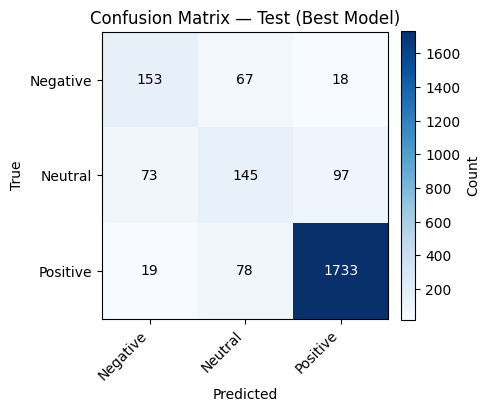

Saved confusion matrix to: results/products_lora_r8\confusion_matrix_test.png


In [20]:
# 10. Evaluation
'''
# 1) Loads the Best saved model + tokenizer (from 9)
# 2) Loads the held-out *test* CSV
# 3) Computes Accuracy + Macro-F1 on test
# 4) Saves a Confusion Matrix figure
# 5) Exports predictions and a metrics.json for your repo/report
'''

# 1) Paths — point MODEL_DIR to the folder you saved in 9A
LORA_RANK = 8                                    # change to 4/16 if needed
MODEL_DIR = f"results/products_lora_r{LORA_RANK}"  # best model directory from training
DEV_CSV   = "data/processed/products_dev.csv"
TEST_CSV  = "data/processed/products_test.csv"

# 2) Label space
LABEL_LIST = ["Negative", "Neutral", "Positive"]
LABEL2ID   = {lab: i for i, lab in enumerate(LABEL_LIST)}
ID2LABEL   = {i: lab for lab, i in LABEL2ID.items()}

# 3) Load tokenizer + best model from disk
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

# canonicalize label spellings to our 3-class set
CANON = {"negative":"Negative","neg":"Negative",
         "neutral":"Neutral",
         "positive":"Positive","pos":"Positive"}

# 4) Clean labels and Load CSVs
def _clean_labels(df, split_name):
    df = df[["text","label"]].copy()

    # normalize labels and drop unknown/missing
    lbl = (df["label"].astype(str).str.strip().str.lower().map(CANON))
    mask_ok = lbl.isin(["Negative","Neutral","Positive"])
    if (~mask_ok).sum() > 0:
        print(f"[Info] Dropped {(~mask_ok).sum()} rows with unknown/missing labels in {split_name}")
    df = df[mask_ok].copy()
    df["label"] = lbl[mask_ok]

    # drop empty text rows
    mask_text = df["text"].astype(str).str.strip().str.len() > 0
    if (~mask_text).sum() > 0:
        print(f"[Info] Dropped {(~mask_text).sum()} rows with empty text in {split_name}")
    df = df[mask_text].copy()

    # map to numeric ids the Trainer expects
    df["labels"] = df["label"].map(LABEL2ID).astype(int)
    return df

def load_split_as_dataset(csv_path, split_name):
    import pandas as pd
    df = pd.read_csv(csv_path)
    df = _clean_labels(df, split_name)
    print(f"[{split_name}] label counts:\n", df["label"].value_counts().to_string())
    # keep only the columns we need; we’ll tokenize next
    return Dataset.from_pandas(df[["text","labels"]], preserve_index=False)

ds_dev  = load_split_as_dataset(DEV_CSV,  "dev")
ds_test = load_split_as_dataset(TEST_CSV, "test")

# 5) Tokenize (same settings as training)
def _tok(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

# remove non-model cols after tokenization (keeps 'labels' only)
remove_cols_dev  = [c for c in ds_dev.column_names  if c not in ["labels","text"]]
remove_cols_test = [c for c in ds_test.column_names if c not in ["labels","text"]]

ds_dev_tok  = ds_dev.map(_tok,  batched=True, remove_columns=remove_cols_dev)
ds_test_tok = ds_test.map(_tok, batched=True, remove_columns=remove_cols_test)

# make sure HF returns PyTorch tensors with fixed shape fields
ds_dev_tok.set_format(type="torch",  columns=["input_ids","attention_mask","labels"])
ds_test_tok.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

# 6) Small helper to run evaluation and return metrics
def evaluate_split(trainer, ds_tok):
    out   = trainer.predict(ds_tok)
    logits = out.predictions
    y_true = np.array(ds_tok["labels"])
    y_pred = np.argmax(logits, axis=-1)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    return acc, f1, y_true, y_pred

# 7) Build a lightweight Trainer for inference
trainer = Trainer(model=model, tokenizer=tokenizer)

# 8) DEV metrics (using the loaded BEST model)
dev_acc, dev_f1, _, _ = evaluate_split(trainer, ds_dev_tok)
print(f"DEV — Accuracy: {dev_acc:.4f} | Macro-F1: {dev_f1:.4f}")

# 9) TEST metrics (using the loaded BEST model)
test_acc, test_f1, y_true, y_pred = evaluate_split(trainer, ds_test_tok)
print(f"TEST — Accuracy: {test_acc:.4f} | Macro-F1: {test_f1:.4f}")

# 10) Save a small results table
os.makedirs(MODEL_DIR, exist_ok=True)
results_csv = os.path.join(MODEL_DIR, "evaluation_summary.csv")
pd.DataFrame(
    [{"split":"dev","accuracy":dev_acc,"macro_f1":dev_f1},
     {"split":"test","accuracy":test_acc,"macro_f1":test_f1}]
).to_csv(results_csv, index=False)
print("Saved results table to:", results_csv)

# 11) Confusion matrix on TEST (PNG)
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABEL_LIST))))
fig_path = os.path.join(MODEL_DIR, "confusion_matrix_test.png")

fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(cm.astype(float), cmap="Blues")
# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Count", rotation=90)

# Ticks & labels
ax.set_xticks(range(len(LABEL_LIST))); ax.set_yticks(range(len(LABEL_LIST)))
ax.set_xticklabels(LABEL_LIST, rotation=45, ha="right")
ax.set_yticklabels(LABEL_LIST)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Test (Best Model)")

# Annotating each cell (auto-switch text color for contrast)
thresh = cm.max() / 2.0 if cm.size > 0 else 0
for (i, j), val in np.ndenumerate(cm):
    color = "white" if val > thresh else "black"
    ax.text(j, i, int(val), ha="center", va="center", color=color, fontsize=10)
    
fig.tight_layout()
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved confusion matrix to:", fig_path)